## 🛠️ Setup & Imports

In [44]:
!nvidia-smi

Tue Jun 16 16:03:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   26C    P8             24W /  300W |      14MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [45]:
%env CUDA_VISIBLE_DEVICES=1

env: CUDA_VISIBLE_DEVICES=1


In [46]:
import json
import math
import os
import zipfile
import glob
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # → consistency/  (pour consistency_models)
sys.path.append('../../..')  # → 4dvarnet-starter-devs/  (pour src)

from consistency_models.consistency_models_CM import (
    ConsistencySamplingAndEditingFewSteps_TimeEmbedding,
    ConsistencyTrainingFewSteps_TimeEmbedding,
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("⚠️  properscoring non installé — CRPS désactivé. Installer avec: pip install properscoring")

## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

In [47]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "/data/users/maxb/4dvarnet-starter-devs/SPDE/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset> Size: 79MB
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * lat        (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 20MB ...
    y          (time, lat, lon) float32 20MB ...
    OI         (time, lat, lon) float64 39MB ...
    H11        (lat, lon) float32 66kB ...
    H22        (lat, lon) float32 66kB ...
    H12        (lat, lon) float32 66kB ...
    Time       (time) int64 2kB ...
    longitude  (lon) int64 1kB ...
    latitude   (lat) int64 1kB ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('la

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)


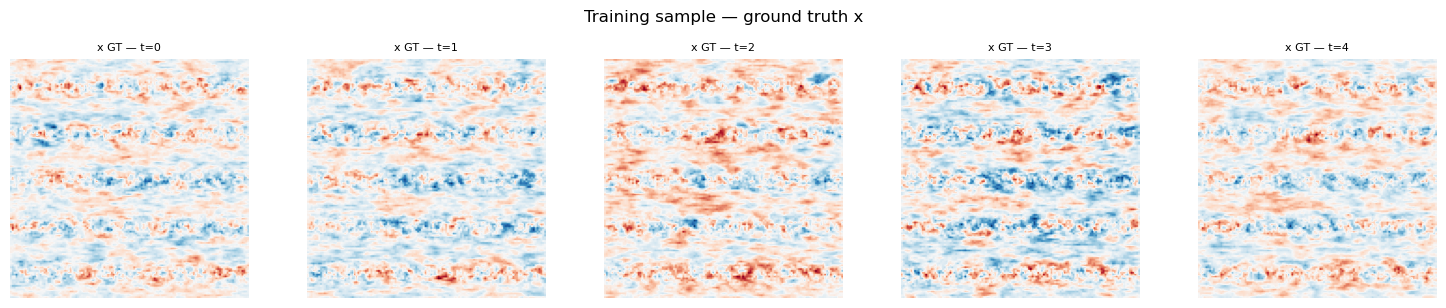

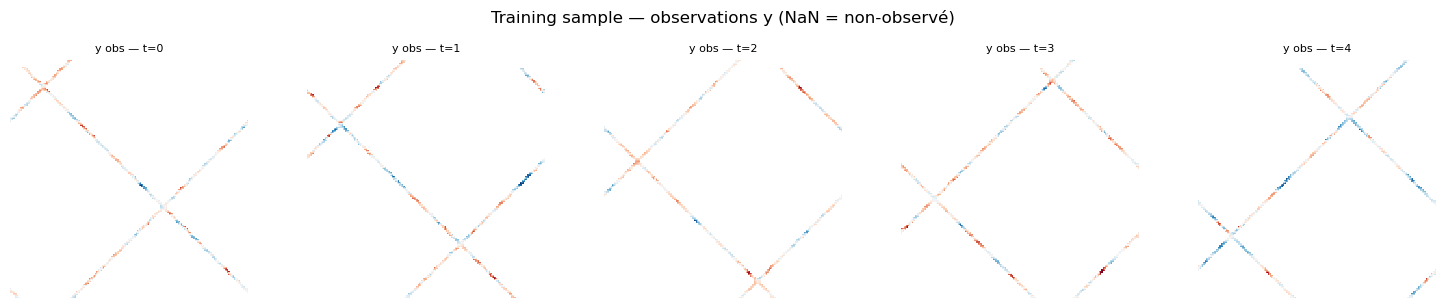

In [48]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = datamodule.window_size
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes — input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    im = ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x GT — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — ground truth x", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    im = ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y obs — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — observations y (NaN = non-observé)", y=1.01)
plt.tight_layout()
plt.show()

### Building Blocks du UNet

Identiques au notebook PWCM SSH (GroupNorm, SelfAttention, UNetBlock, Downsample, Upsample, TimeLevelEmbedding).

In [49]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeLevelEmbedding(nn.Module):
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Padding utilities (pour gérer 100×100 → 104×104, multiple de 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)  # left, right, top, bottom
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### UNet (Consistency Model)

Le UNet prend en entrée la concaténation `(x_noisy, y_filled, mask_obs)` → `3×C` canaux d'entrée.  
Conditionné par deux embeddings temporels `σ` et `σ'` (concaténés → `2×time_level_channels`).  
Un padding réflexion à multiple de 8 est appliqué en entrée et retiré en sortie.

In [50]:
@dataclass
class UNetConfig:
    channels: int = 5                                        # = window_size
    time_level_channels: int = 128
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class UNet(nn.Module):
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config

        # input = (x_noisy, y_filled, mask_obs) → 3 * channels
        self.input_projection = nn.Conv2d(
            config.channels * 3,
            config.top_blocks_channels[0],
            kernel_size=3, padding="same",
        )
        self.time_level_embedding = TimeLevelEmbedding(
            config.time_level_channels, config.time_level_scale
        )

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.output_projection = nn.Conv2d(
            config.top_blocks_channels[0], config.channels, kernel_size=3, padding="same"
        )

    def forward(self, x: Tensor, y: Tensor, time: Tensor, time_prime: Tensor) -> Tensor:
        mask_obs = (~torch.isnan(y)).to(x.dtype)
        y_filled = torch.nan_to_num(y, nan=0.0)

        # Pad H×W to nearest multiple of 8 (100×100 → 104×104)
        inp = torch.cat((x, y_filled, mask_obs), dim=1)   # (B, 3C, H, W)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h = self.input_projection(inp)

        # Two sigma embeddings concatenated along channel dim
        emb1 = self.time_level_embedding(time)
        emb2 = self.time_level_embedding(time_prime)
        time_level = torch.cat([emb1, emb2], dim=1)   # (B, 2*TLC, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)   # restaure H×W original

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


# Sanity check : 100×100 sera paddé à 104×104 en interne
C = datamodule.window_size
summary(
    UNet(UNetConfig(channels=C)),
    input_size=(
        (1, C, 100, 100),  # x_noisy
        (1, C, 100, 100),  # y_obs
        (1,),               # sigma
        (1,),               # sigma_prime
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 5, 100, 100]          --
├─Conv2d: 1-1                                 [1, 64, 104, 104]         8,704
├─TimeLevelEmbedding: 1-2                     [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─TimeLevelEmbedding: 1-3                     [1, 128, 1, 1]            (recursive)
│    └─Sequential: 2-2                        [1, 128, 1, 1]            (recursive)
│    │    └─Linear: 3-5                       [1, 512]                  (recursive)
│    │    └─SiLU: 3-6                         [1, 512]   

### LightningModule — LitConsistencyModel

Identique au notebook PWCM SSH. Le `training_step` appelle `ConsistencyTrainingFewSteps_TimeEmbedding` avec `batch.tgt` (vérité terrain) et `batch.input` (observations avec NaN).

In [51]:

@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    eval_nsteps: int = 10   # steps de sampling pour l'évaluation en fin d'epoch


class LitConsistencyModel(LightningModule):
    def __init__(
        self,
        consistency_training: ConsistencyTrainingFewSteps_TimeEmbedding,
        student_model: UNet,
        teacher_model: UNet,
        ema_student_model: UNet,
        config: LitConsistencyModelConfig,
    ) -> None:
        super().__init__()
        self.consistency_training = consistency_training
        self.student_model = student_model
        self.teacher_model = teacher_model
        self.ema_student_model = ema_student_model
        self.config = config
        self.num_timesteps = self.consistency_training.initial_timesteps
        self._val_batch = None   # sera rempli dans on_fit_start

        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    def on_fit_start(self) -> None:
        """Stocke un batch de validation fixe pour l'évaluation en fin d'epoch."""
        try:
            dl = self.trainer.datamodule.val_dataloader()
            batch = next(iter(dl))
            if isinstance(batch, list):
                batch = batch[0]
            self._val_batch = batch
            print(f"✅ Val batch chargé : tgt={batch.tgt.shape}")
        except Exception as e:
            print(f"⚠️  Impossible de charger un batch de validation : {e}")

    def on_train_epoch_start(self) -> None:
        print(f"[Epoch {self.current_epoch}] num_timesteps={self.num_timesteps}")

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        output = self.consistency_training(
            self.student_model,
            self.teacher_model,
            batch.tgt,
            batch.input,
            self.global_step,
            10000,
        )
        self.num_timesteps = output.num_timesteps

        if batch_idx == 0:
            print(f"[Epoch {self.current_epoch}] sigmas={output.sigmas}")

        loss = F.mse_loss(
            output.predicted_next_from_intermediate,
            output.target_next_from_current,
        )
        self.log_dict({
            "train_loss":    loss,
            "num_timesteps": float(output.num_timesteps),
        })
        return loss

    def on_train_epoch_end(self) -> None:
        """Calcule le RMSE de reconstruction (10 steps, modèle EMA) sur le batch de validation."""
        if self._val_batch is None:
            print(f"[Epoch {self.current_epoch}]  ⚠️  Pas de batch de validation disponible.")
            return

        device = self.device
        dtype  = next(self.ema_student_model.parameters()).dtype

        x_gt = self._val_batch.tgt.to(device=device, dtype=dtype)
        y    = self._val_batch.input.to(device=device, dtype=dtype)
        B, C, H, W = x_gt.shape

        sampler = ConsistencySamplingAndEditingFewSteps_TimeEmbedding()
        self.ema_student_model.eval()

        with torch.no_grad():
            noise = torch.randn((B, C, H, W), device=device, dtype=dtype)
            x_hat, _ = sampler(
                self.ema_student_model,
                noise,
                y,
                nsteps=self.config.eval_nsteps,
                clip_denoised=False,
                verbose=False,
                stochastic=False,
            )

        rmse = (x_hat.float() - x_gt.float()).pow(2).mean().sqrt().item()
        print(
            f"[Epoch {self.current_epoch}]  "
            f"Val RMSE ({self.config.eval_nsteps} steps, EMA) = {rmse:.4f}"
        )
        self.log("val_rmse_ema", rmse)

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        ema_decay_rate = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.consistency_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model, self.student_model, ema_decay_rate)
        self.log_dict({"ema_decay_rate": ema_decay_rate})
        update_ema_model_(
            self.ema_student_model,
            self.student_model,
            self.config.student_model_ema_decay_rate,
        )

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.student_model.parameters(),
            lr=self.config.lr, betas=self.config.betas,
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]


## 🚀 Training

In [52]:
%tensorboard --logdir=logs_CT_CM_spde --port 6007

UsageError: Line magic function `%tensorboard` not found.


In [63]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False


def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, 'last.ckpt')
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f'Valid checkpoint: {last_ckpt}')
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, '*.ckpt'))
         if 'last' not in os.path.basename(p)],
        key=lambda p: float(p.split('train_loss=')[-1].replace('.ckpt', ''))
        if 'train_loss=' in p else float('inf'),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f'Valid checkpoint: {ckpt_path}')
            return ckpt_path
    print('No valid checkpoint found. Starting from scratch.')
    return None


C = datamodule.window_size

LOG_DIR        = 'logs_CT_CM_spde'
LOG_VERSION    = 'v1'
CKPT_DIR       = os.path.join(LOG_DIR, LOG_VERSION, 'checkpoints')
MODEL_PATH     = os.path.join(LOG_DIR, LOG_VERSION, 'best_model')

RESET_TRAINING   = False  # True = relancer depuis zero (ignore les checkpoints)
RESUME_FROM_LAST = True   # True = reprend le dernier checkpoint valide

if RESET_TRAINING:
    resume_ckpt = None
    print('RESET_TRAINING=True -- demarrage depuis zero')
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

ct = ConsistencyTrainingFewSteps_TimeEmbedding(final_timesteps=17)

student_model     = UNet(UNetConfig(channels=C))
teacher_model     = UNet(UNetConfig(channels=C))
ema_student_model = UNet(UNetConfig(channels=C))
teacher_model.load_state_dict(student_model.state_dict())
ema_student_model.load_state_dict(student_model.state_dict())

lit_cm = LitConsistencyModel(
    ct, student_model, teacher_model, ema_student_model,
    LitConsistencyModelConfig(lr_scheduler_iters=1000),
)

trainer = Trainer(
    accelerator='gpu', max_epochs=2500, accumulate_grad_batches=4,
    precision='16-mixed', log_every_n_steps=1,
    logger=TensorBoardLogger('.', name=LOG_DIR, version=LOG_VERSION),
    callbacks=[
        LearningRateMonitor(logging_interval='step'),
        ModelCheckpoint(
            dirpath=CKPT_DIR, monitor='train_loss',
            save_top_k=3, save_last=True,
            filename='{epoch:03d}-{step}-{train_loss:.4f}',
        ),
    ],
)

seed_everything(42)
trainer.fit(lit_cm, datamodule, ckpt_path=resume_ckpt)

lit_cm.ema_student_model.save_pretrained(MODEL_PATH)
print(f'EMA model saved to: {MODEL_PATH}')


Valid checkpoint: logs_CT_CM_spde/v1/checkpoints/last.ckpt


Using 16bit Automatic Mixed Precision (AMP)
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint direc

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]

  | Name              | Type | Params
-------------------------------------------
0 | student_model     | UNet | 32.9 M
1 | teacher_model     | UNet | 32.9 M
2 | ema_student_model | UNet | 32.9 M
-------------------------------------------
32.9 M    Trainable params
65.7 M    Non-trainable params
98.6 M    Total params
394.414   Total estimated model params size (MB)
Restored all states from the checkpoint at logs_CT_CM_spde/v1/checkpoints/last.ckpt


✅ Val batch chargé : tgt=torch.Size([1, 5, 128, 128])


/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 64 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

[Epoch 389] num_timesteps=2
[Epoch 389] sigmas=tensor([0.0000, 0.0400, 0.0800, 0.1200, 0.1600, 0.2000, 0.2400, 0.2800, 0.3200,
        0.3600, 0.4000, 0.4400, 0.4800, 0.5200, 0.5600, 0.6000, 0.6400, 0.6800,
        0.7200, 0.7600, 0.8000, 0.8400, 0.8800, 0.9200, 0.9600, 1.0000],
       device='cuda:0')
[Epoch 389]  Val RMSE (10 steps, EMA) = 0.9187
[Epoch 390] num_timesteps=26
[Epoch 390] sigmas=tensor([0.0000, 0.0400, 0.0800, 0.1200, 0.1600, 0.2000, 0.2400, 0.2800, 0.3200,
        0.3600, 0.4000, 0.4400, 0.4800, 0.5200, 0.5600, 0.6000, 0.6400, 0.6800,
        0.7200, 0.7600, 0.8000, 0.8400, 0.8800, 0.9200, 0.9600, 1.0000],
       device='cuda:0')
[Epoch 390]  Val RMSE (10 steps, EMA) = 0.9185
[Epoch 391] num_timesteps=26
[Epoch 391] sigmas=tensor([0.0000, 0.0400, 0.0800, 0.1200, 0.1600, 0.2000, 0.2400, 0.2800, 0.3200,
        0.3600, 0.4000, 0.4400, 0.4800, 0.5200, 0.5600, 0.6000, 0.6400, 0.6800,
        0.7200, 0.7600, 0.8000, 0.8400, 0.8800, 0.9200, 0.9600, 1.0000],
       device='c

/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


EMA model saved to: logs_CT_CM_spde/v1/best_model


## 🎲 Sampling & Evaluation

In [64]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

unet = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"✅ Model loaded from: {MODEL_PATH}")

✅ Model loaded from: logs_CT_CM_spde/v1/best_model


### Batch de test

In [65]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

Global seed set to 42


### Génération d'ensemble (N_SAMPLES membres)

In [66]:
N_SAMPLES = 10
consistency_sampling = ConsistencySamplingAndEditingFewSteps_TimeEmbedding()

C  = datamodule.window_size
H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]  # 100×100

samples = []
samples_process = []

with torch.no_grad():
    for i in range(N_SAMPLES):
        sample, sample_process = consistency_sampling(
            unet,
            torch.randn((1, C, H, W), device=device, dtype=dtype),
            batch.input.to(device=device, dtype=dtype),
            nsteps=15,
            clip_denoised=False,
            verbose=(i == 0),
            stochastic=True,
        )
        samples.append(sample)
        samples_process.append(sample_process)
        print(f"  Sample {i+1}/{N_SAMPLES} done", end="\r")
print(f"\n✅ {N_SAMPLES} membres d'ensemble générés")

# Moyenne et écart-type de l'ensemble
ensemble = torch.stack(samples, dim=0).squeeze(1)   # (N, C, H, W)
ens_mean = ensemble.mean(dim=0)                      # (C, H, W)
ens_std  = ensemble.std(dim=0)                       # (C, H, W)

  Sample 10/10 done
✅ 10 membres d'ensemble générés


## 📊 Métriques — Consistency Model vs OI

Évaluation au **centre de la fenêtre d'assimilation** (`t=2`, `C=5`).

| Métrique | Description |
|---|---|
| **Score ↑** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE ↓** | Root Mean Square Error vs GT |
| **Spread** | Écart-type moyen de l'ensemble |
| **CRPS ↓** | Continuous Ranked Probability Score aux pixels **observés** |
| **λx ↓** | Échelle résolue (px): longueur d'onde où spectral score = 0.5 |

t=2 | sigma(GT)=0.2475 | obs coverage=5.2%

## Metriques @ t=2 -- pixel = 1 km



,Score ↑,RMSE ↓,σ_GT,σ_pred,CRPS ↓,λx [px]
Method,,,,,,
CM (ens. mean),0.193,0.1998,0.2475,0.2284,0.0514,27.1
OI baseline,0.108,0.2208,0.2475,0.1484,--,44.6


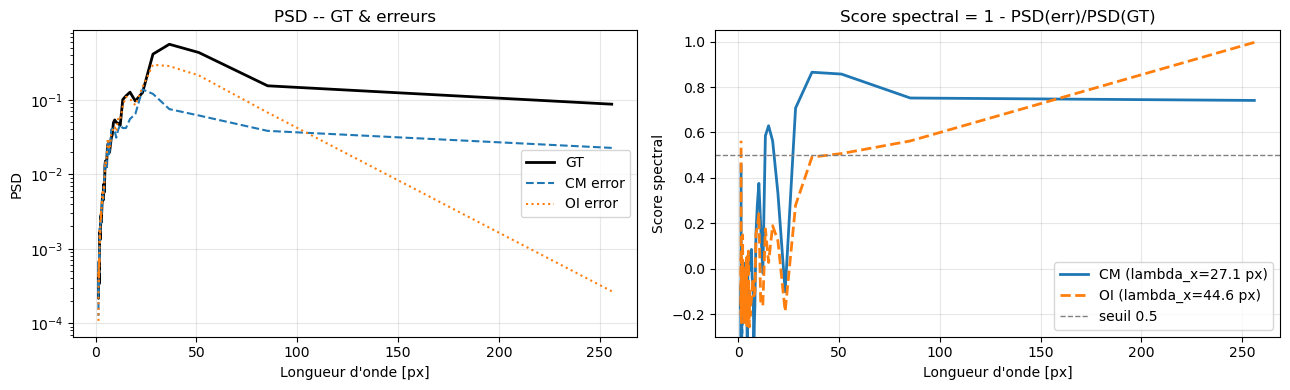

In [67]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import psd_spectral_score, resolved_scale

T_EVAL = datamodule.window_size // 2   # = 2 pour C=5
DX_PX  = 1.0                           # 1 pixel = 1 km (hypothese)

# Champs au temps T_EVAL
m_norm, s_norm = datamodule.norm_stats()

gt_n   = batch.tgt[0, T_EVAL].float().numpy()                 # (H, W) normalise
gt_p   = gt_n   * s_norm + m_norm                             # physique

ens_n  = ensemble[:, T_EVAL].float().cpu().numpy()            # (N, H, W) normalise
ens_p  = ens_n  * s_norm + m_norm                             # physique

mean_n = ens_mean[T_EVAL].float().cpu().numpy()               # (H, W) normalise
mean_p = mean_n * s_norm + m_norm                             # physique

start_t = datamodule.test_ds.indices[0]
oi_p    = datamodule.oi[start_t + T_EVAL].astype(np.float32)  # (H, W) physique

obs_mask = ~np.isnan(batch.input[0, T_EVAL].float().numpy())  # (H, W) bool

sigma_gt = float(np.nanstd(gt_p))
print(f't={T_EVAL} | sigma(GT)={sigma_gt:.4f} | obs coverage={obs_mask.mean()*100:.1f}%')

def _metrics_row(pred_p, gt_p, label, ens_p_arr=None, obs_mask=None, dx=DX_PX):
    sigma      = float(np.nanstd(gt_p))
    rmse       = float(np.sqrt(np.nanmean((pred_p - gt_p) ** 2)))
    score      = 1.0 - rmse / sigma
    sigma_pred = float(np.nanstd(pred_p))
    wl, _, _, spec = psd_spectral_score(pred_p, gt_p, dx=dx)
    lambda_x   = resolved_scale(wl, spec, threshold=0.5)
    crps_val   = np.nan
    if ens_p_arr is not None and HAS_PROPERSCORING and obs_mask is not None:
        obs_ij = np.argwhere(obs_mask)
        if len(obs_ij) > 0:
            crps_val = float(np.mean([
                crps_ensemble(float(gt_p[i, j]), ens_p_arr[:, i, j])
                for i, j in obs_ij
            ]))
    return {
        'Method'   : label,
        'Score up' : f'{score:.3f}',
        'RMSE down': f'{rmse:.4f}',
        'sigma_GT' : f'{sigma:.4f}',
        'sigma_pred': f'{sigma_pred:.4f}',
        'CRPS down': f'{crps_val:.4f}' if not np.isnan(crps_val) else '--',
        'lambda_x px': f'{lambda_x:.1f}' if not np.isnan(lambda_x) else '?',
    }, wl, spec

row_cm, wl_cm, spec_cm = _metrics_row(mean_p, gt_p, 'CM (ens. mean)',
                                        ens_p_arr=ens_p, obs_mask=obs_mask)
row_oi, wl_oi, spec_oi = _metrics_row(oi_p,   gt_p, 'OI baseline')

df_metrics = pd.DataFrame([row_cm, row_oi]).set_index('Method')
df_metrics.columns = ['Score ↑','RMSE ↓','σ_GT','σ_pred','CRPS ↓','λx [px]']
print(f'\n## Metriques @ t={T_EVAL} -- pixel = {DX_PX:.0f} km\n')
display(df_metrics)

# Spectral score plot
_, psd_gt_r, psd_err_cm, _ = psd_spectral_score(mean_p, gt_p, dx=DX_PX)
_, _,         psd_err_oi, _ = psd_spectral_score(oi_p,   gt_p, dx=DX_PX)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
valid = np.isfinite(wl_cm) & np.isfinite(psd_gt_r)
ax.semilogy(wl_cm[valid], psd_gt_r[valid],   'k-',   lw=2,   label='GT')
ax.semilogy(wl_cm[valid], psd_err_cm[valid],  'C0--', lw=1.5, label='CM error')
valid_oi = np.isfinite(wl_oi) & np.isfinite(psd_err_oi)
ax.semilogy(wl_oi[valid_oi], psd_err_oi[valid_oi], 'C1:', lw=1.5, label='OI error')
ax.set_xlabel("Longueur d'onde [px]"); ax.set_ylabel('PSD')
ax.set_title('PSD -- GT & erreurs'); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1]
valid_cm = np.isfinite(wl_cm) & np.isfinite(spec_cm)
valid_oi = np.isfinite(wl_oi) & np.isfinite(spec_oi)
lambda_x_cm = resolved_scale(wl_cm, spec_cm)
lambda_x_oi = resolved_scale(wl_oi, spec_oi)
lbl_cm = f'CM (lambda_x={lambda_x_cm:.1f} px)' if not np.isnan(lambda_x_cm) else 'CM'
lbl_oi = f'OI (lambda_x={lambda_x_oi:.1f} px)' if not np.isnan(lambda_x_oi) else 'OI'
ax.plot(wl_cm[valid_cm], spec_cm[valid_cm], 'C0-', lw=2, label=lbl_cm)
ax.plot(wl_oi[valid_oi], spec_oi[valid_oi], 'C1--', lw=2, label=lbl_oi)
ax.axhline(0.5, color='gray', lw=1, ls='--', label='seuil 0.5')
ax.set_xlabel("Longueur d'onde [px]"); ax.set_ylabel('Score spectral')
ax.set_title('Score spectral = 1 - PSD(err)/PSD(GT)')
ax.set_ylim(-0.3, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Figures publication-ready -- comparaison & incertitude

  Saved: figures/CM_spde/CM_spde_obs.png


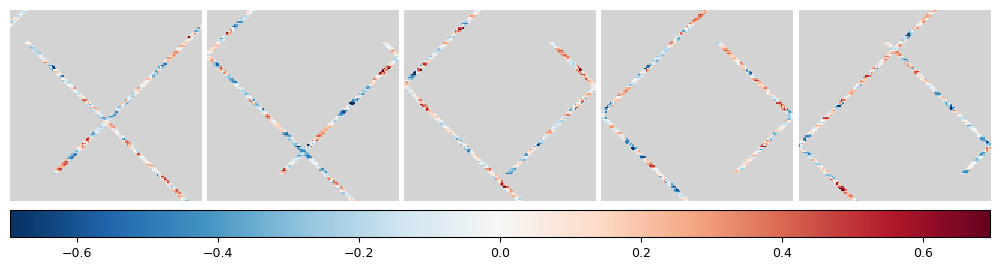

  Saved: figures/CM_spde/CM_spde_gt.png


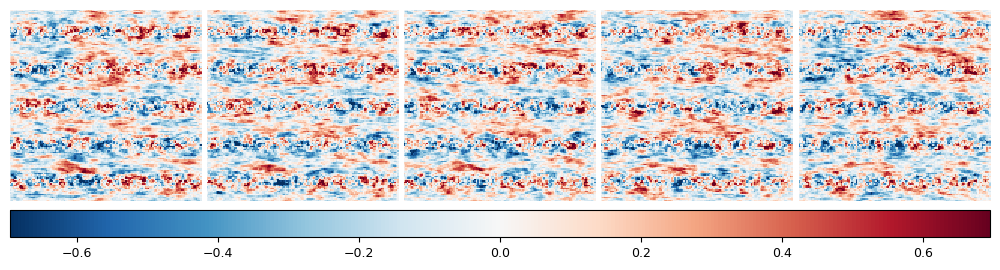

  Saved: figures/CM_spde/CM_spde_oi.png


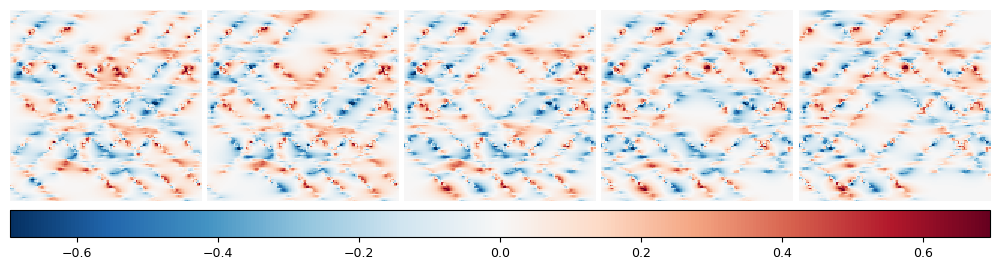

  Saved: figures/CM_spde/CM_spde_cm_mean.png


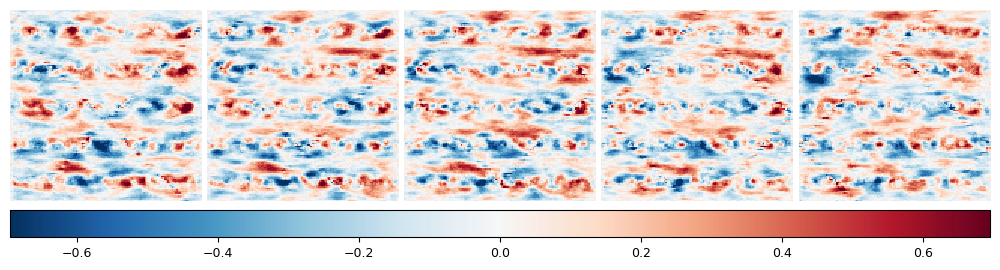

  Saved: figures/CM_spde/CM_spde_cm_spread.png


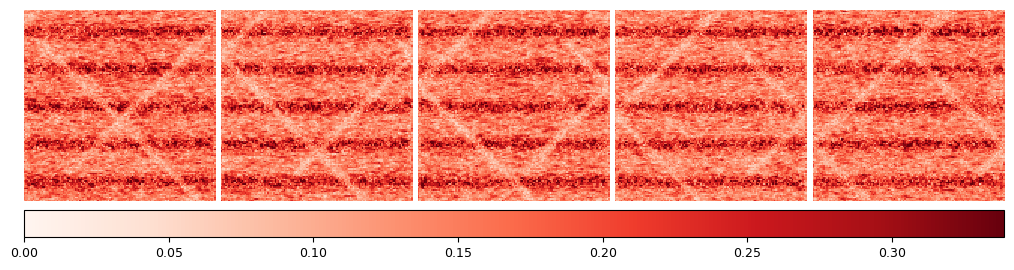

  Saved: figures/CM_spde/CM_spde_member0.png


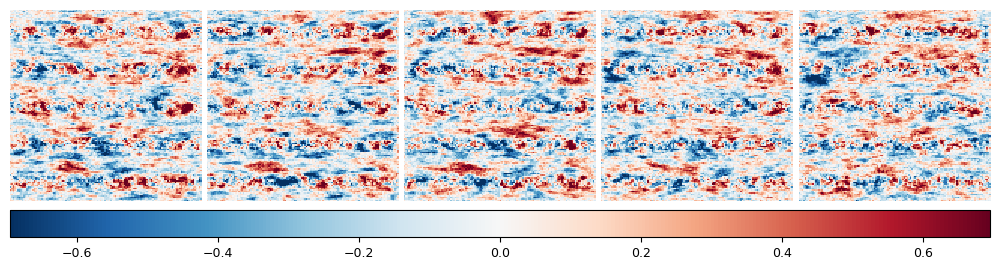

  Saved: figures/CM_spde/CM_spde_member1.png


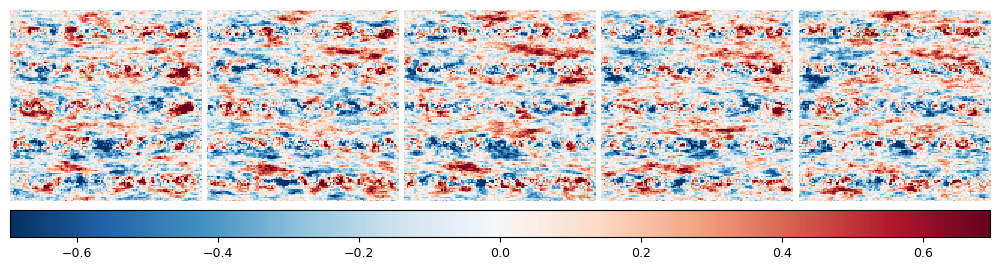

In [68]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'CM_spde'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

C       = datamodule.window_size

# Physical fields over full assimilation window
m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]

obs_phys  = batch.input[0].float().numpy() * s_norm + m_norm   # (C,H,W) NaN ok
gt_phys   = batch.tgt[0].float().numpy()   * s_norm + m_norm   # (C,H,W)
oi_phys   = datamodule.oi[start_t: start_t + C].astype(np.float32)  # (C,H,W)
mean_phys = ens_mean.float().cpu().numpy() * s_norm + m_norm    # (C,H,W)
std_phys  = ens_std.float().cpu().numpy()  * s_norm             # (C,H,W)
mbr0_phys = ensemble[0].float().cpu().numpy() * s_norm + m_norm # (C,H,W)
mbr1_phys = ensemble[1].float().cpu().numpy() * s_norm + m_norm # (C,H,W)

# Shared colorbar range for all field images
vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f
vmax_s = float(np.nanpercentile(std_phys, 99))

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')
cmap_s = plt.cm.Reds.copy();   cmap_s.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    # One image per variable: 1 row x C cols, horizontal colorbar, no title
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C,
                  left=0.01, right=0.99,
                  top=0.99,
                  bottom=0.01,
                  height_ratios=[FH, CB_H],
                  hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

# One figure per variable (1 row x C cols, shared vmin/vmax per type)
figures = [
    (obs_phys,  f'{FIG_TAG}_obs',     vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',      vmin_f, vmax_f, cmap_f),
    (oi_phys,   f'{FIG_TAG}_oi',      vmin_f, vmax_f, cmap_f),
    (mean_phys, f'{FIG_TAG}_cm_mean', vmin_f, vmax_f, cmap_f),
    (std_phys,  f'{FIG_TAG}_cm_spread', 0.0,  vmax_s, cmap_s),
    (mbr0_phys, f'{FIG_TAG}_member0', vmin_f, vmax_f, cmap_f),
    (mbr1_phys, f'{FIG_TAG}_member1', vmin_f, vmax_f, cmap_f),
]

for data, fname, vmin, vmax, cmap in figures:
    _save_strip(data, fname, vmin, vmax, cmap)

### Transport process -- trajectoire de debruitage (membre 0)

  Saved: figures/CM_spde/CM_spde_transport.png


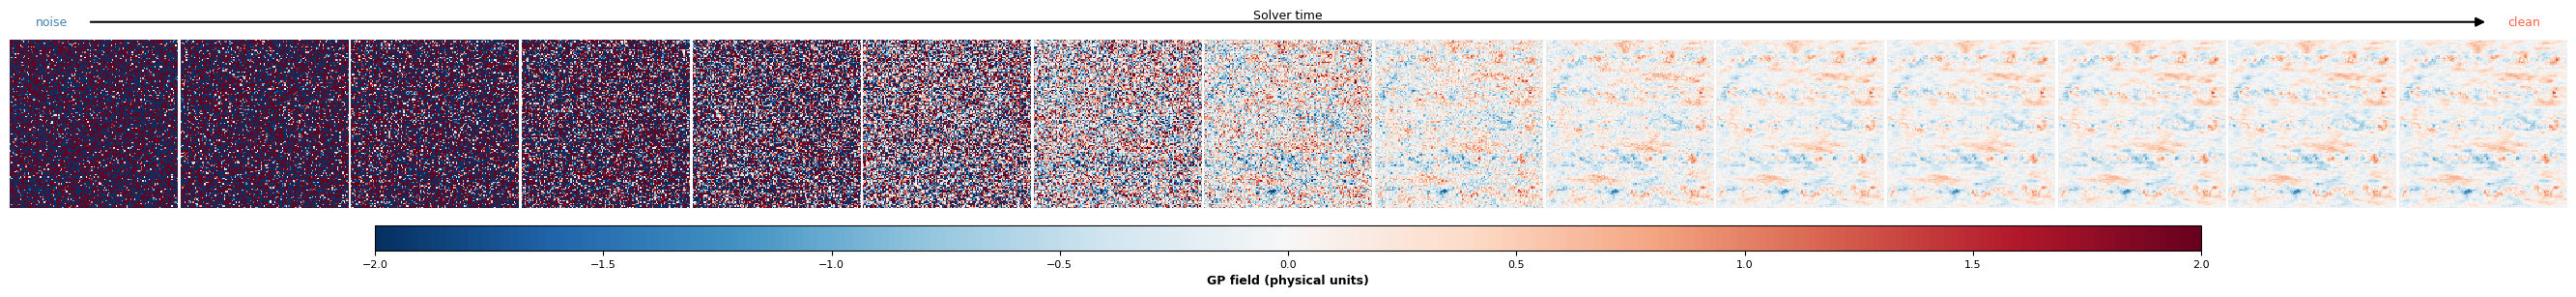

In [69]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

T_CH   = datamodule.window_size // 2   # canal temporel affiche (t=2)
N_SHOW = 15                             # max frames

proc = samples_process[0]
if proc.ndim == 5:   # (nsteps, B, C, H, W)
    transport_n = proc[:, 0, T_CH, :, :].float().cpu().numpy()
else:                # (nsteps, 1, C, H, W)
    transport_n = proc[:, 0, 0, T_CH, :, :].float().cpu().numpy()
transport_p = transport_n * s_norm + m_norm

nfr = transport_p.shape[0]
stride = max(1, nfr // N_SHOW)
idx_show = list(range(0, nfr, stride))
if (nfr - 1) not in idx_show:
    idx_show.append(nfr - 1)
frames = transport_p[idx_show]
nf = len(frames)

# Layout (all in inches, from bottom to top)
FW, FH   = 1.8, 1.8   # frame width / height
ARR_H    = 0.28        # arrow zone
GAP_1    = 0.14        # gap: arrow -> colorbar
CB_H     = 0.26        # colorbar height
GAP_2    = 0.16        # gap: colorbar -> images

fig_w = nf * FW
fig_h = ARR_H + GAP_1 + CB_H + GAP_2 + FH

# Figure-fraction positions (y = 0 at bottom)
arr_y_in   = ARR_H / 2                                # arrow center (inches)
cb_bot_in  = ARR_H + GAP_1                            # colorbar bottom (inches)
img_bot_in = ARR_H + GAP_1 + CB_H + GAP_2            # image strip bottom (inches)

arr_y_f   = arr_y_in   / fig_h
cb_bot_f  = cb_bot_in  / fig_h
cb_h_f    = CB_H       / fig_h
img_bot_f = img_bot_in / fig_h

fig = plt.figure(figsize=(fig_w, fig_h))

# Image strip (GridSpec leaves margins via bottom/top)
gs = GridSpec(1, nf, left=0.01, right=0.99,
              top=0.99, bottom=img_bot_f,
              hspace=0, wspace=0.02)

vmax_t = float(np.nanpercentile(np.abs(transport_p), 99))
vmax_t = 2
cmap_t = plt.cm.RdBu_r
for i in range(nf):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(frames[i], origin='lower', cmap=cmap_t,
              vmin=-vmax_t, vmax=vmax_t, interpolation='nearest')
    ax.axis('off')

# Horizontal colorbar
cb_ax = fig.add_axes([0.15, cb_bot_f, 0.70, cb_h_f])
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(-vmax_t, vmax_t))
sm.set_array([])
cb = fig.colorbar(sm, cax=cb_ax, orientation='horizontal')
cb.set_label('GP field (physical units)', fontsize=9, fontweight='bold')
cb.ax.tick_params(labelsize=8)

# Temporal arrow
fig.add_artist(mpatches.FancyArrowPatch(
    (0.04, 1+arr_y_f), (0.96, 1+arr_y_f),
    transform=fig.transFigure, arrowstyle='-|>',
    color='black', mutation_scale=14, linewidth=1.5,
))
fig.text(0.02, 1+arr_y_f, 'noise', va='center', ha='left',  fontsize=9, color='steelblue')
fig.text(0.98, 1+arr_y_f, 'clean', va='center', ha='right', fontsize=9, color='tomato')
fig.text(0.50, 1+arr_y_f, 'Solver time', va='bottom', ha='center', fontsize=9)

fpath = os.path.join(FIG_DIR, f'{FIG_TAG}_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()